# Fisik vs. Digital: Analisis Perbandingan Kerentanan Media Penyimpanan Data Kesehatan US #
Kelompok 2:
1. Adhitya Bayu Pratama   : 5027261045
2. Via Nur Belaya         : 5027261060
3. Raditya Langit Nugraha : 5027261072
<br>

**Topik: Cyber Security - Data Breaches**

## Memuat dan menampilkan data ##

In [1]:
import kagglehub

# Download dataset versi terbaru
path = kagglehub.dataset_download("thedevastator/major-us-health-data-breaches")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\thedevastator\major-us-health-data-breaches\versions\2


In [57]:
import pandas as pd
import matplotlib as mt
import numpy as np
import seaborn as se

df = pd.read_csv('breach_report.csv', index_col=0) #read data

df.index += 1 #agar index mulai dari 1, bukan 0

# Mengubah tipe data "Individuals Affected" dari float menjadi nullable integer
df['Individuals Affected'] = df['Individuals Affected'].astype('Int64')

pd.set_option('display.max_rows', None) #tampilkan SEMUA data yang di-read
pd.set_option('display.max_colwidth', None) #agar text di 1 kolom tidak disingkat jika terlalu panjang

print("Jumlah baris, kolom:", df.shape) 
print("Satu baris/row mewakilkan satu perusahaan di bidang kesehatan (termasuk rumah sakit) di Amerika Serikat yang terkena breach. \n")

df #Menampilkan data dalam bentuk table array

Jumlah baris, kolom: (1654, 9)
Satu baris/row mewakilkan satu perusahaan di bidang kesehatan (termasuk rumah sakit) di Amerika Serikat yang terkena breach. 



,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present,Web Description
index,,,,,,,,,
1,Brooke Army Medical Center,TX,Healthcare Provider,1000,10/21/09,Theft,Paper/Films,No,"A binder containing the protected health information (PHI) of up to 1,272 individuals was stolen from a staff member's vehicle. The PHI included names, telephone numbers, detailed treatment notes, and possibly social security numbers. In response to the breach, the covered entity (CE) sanctioned the workforce member and developed a new policy requiring on-call staff members to submit any information created during their shifts to the main office instead of adding it to the binder. Following OCR's investigation, the CE notified the local media about the breach."
2,"Mid America Kidney Stone Association, LLC",MO,Healthcare Provider,1000,10/28/09,Theft,Network Server,No,"Five desktop computers containing unencrypted electronic protected health information (e-PHI) were stolen from the covered entity (CE). Originally, the CE reported that over 500 persons were involved, but subsequent investigation showed that about 260 persons were involved. The ePHI included demographic and financial information. The CE provided breach notification to affected individuals and HHS. Following the breach, the CE improved physical security by installing motion detectors and alarm systems security monitoring. It improved technical safeguards by installing enhanced antivirus and encryption software. As a result of OCR's investigation the CE updated its computer password policy."
3,Alaska Department of Health and Social Services,AK,Healthcare Provider,501,10/30/09,Theft,"Other, Other Portable Electronic Device",No,\N
4,"Health Services for Children with Special Needs, Inc.",DC,Health Plan,3800,11/17/09,Loss,Laptop,No,"A laptop was lost by an employee while in transit on public transportation. The computer contained the protected health information of 3800 individuals. The protected health information involved in the breach included names, Medicaid ID numbers, dates of birth, and primary physicians. In response to this incident, the covered entity took steps to enforce the requirements of the Privacy & Security Rules. The covered entity has installed encryption software on all employee computers, strengthened access controls including passwords, reviewed and updated security policies and procedures, and updated it risk assessment. In addition, all employees received additional security training. \"
5,"Mark D. Lurie, MD",CA,Healthcare Provider,5166,11/20/09,Theft,Desktop Computer,No,"A shared Computer that was used for backup was stolen on 9/27/09 from the reception desk area of the covered entity. The Computer contained certain electronic protected health information (ePHI) of 5,166 individuals who were patients of the CE, The ePHI involved in the breach included names, dates of birth, and clinical information, but there were no social security numbers, financial information, addresses, phone numbers, or other ePHI in any of the reports on the disks or the hard drive on the stolen Computer. Following the breach, the CE: notified all 5,166 affected indiv's and the appropriate media; added technical safeguards of encryption for all ePHI stored on the USB flash drive or the CD used on the replacement computer; all passwords are strong; all computers are password protected; added physical safeguards by keeping new portable devices locked when not in use in a secure combination safe in doctor's private office or in a secure filing cabinet; and added administrative safeguards by requiring annual refresher retraining of CE staff for Privacy and Security Rules as well as requiring immediate retraining of cleaning staff in both Rules, which has already taken place. \"
6,"L. Douglas Carlson, M.D.",CA,Healthcare Provider,5257,11/20/09,Theft,Desktop Computer,No,"A shared Computer that

In [3]:
#Hapus kolom yang tidak diperlukan dan/atau tidak sesuai dengan tujuan analisis
df = df.drop(columns=['State', 'Breach Submission Date', 'Business Associate Present', 'Web Description']) 
df.head() #Nampilin 5 data pertama sebagai contoh

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
1,Brooke Army Medical Center,Healthcare Provider,1000,Theft,Paper/Films
2,"Mid America Kidney Stone Association, LLC",Healthcare Provider,1000,Theft,Network Server
3,Alaska Department of Health and Social Services,Healthcare Provider,501,Theft,"Other, Other Portable Electronic Device"
4,"Health Services for Children with Special Needs, Inc.",Health Plan,3800,Loss,Laptop
5,"Mark D. Lurie, MD",Healthcare Provider,5166,Theft,Desktop Computer


## Deskripsi data dan kamus data ##

1. Sumber data dan Lisensi:
    - License: https://creativecommons.org/licenses/by/4.0/
        <br> You are free to:
        <br>Share - copy and redistribute the material in any medium or format for any purpose, even commercially.
        <br>Adapt - remix, transform, and build upon the material for any purpose, even commercially.
            <br> <br> Under the following terms:
              <br> Attribution - You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any   reasonable manner, but not in any way that suggests the licensor endorses you or your use.
            <br> No additional restrictions - You may not apply legal terms or technological measures that legally restrict others from doing anything the license permits.
            <br> <br> Notices:
            <br> You do not have to comply with the license for elements of the material in the public domain or where your use is permitted by an applicable exception or limitation.
            <br> No warranties are given. The license may not give you all of the permissions necessary for your intended use. For example, other rights such as publicity, privacy, or moral rights may limit how you use the material.
      <br> <br> 
    - Source: https://www.kaggle.com/datasets/thedevastator/major-us-health-data-breaches,
        <br> Original source: data.world (Web discontinued) & HHS OCR Breach Portal: https://ocrportal.hhs.gov/ocr/breach/breach_report_hip.jsf
    <br>

2. Siapa yang mengumpulkan data? kapan? dan bagaimana?
    - Siapa: Data ini dikumpulkan oleh Office for Civil Rights (OCR) di bawah naungan departemen kesehatan Amerika Serikat atau U.S. Department of Health and Human Services (HHS). <br>
    - Kapan: Data direkam secara berkelanjutan sejak HIPAA Breach Notification Rule mulai diberlakukan pada tahun 2009. Pengumpulannya dilakukan secara real-time dan institusi wajib melaporkan insiden ke HHS selambat-lambatnya 60 hari sejak **kebocoran pertama kali ditemukan**, bukan dihitung dari hari terjadinya kebocoran.   <br>
    - Bagaimana: Data ini tidak dikumpulkan melalui survei atau pencarian independen oleh peneliti, melainkan lewat mandat hukum wajib lapor (HIPAA/HITECH Act)
   <br>

3. Jumlah baris dan kolom
   - Jumlah baris = 1654
   - Jumlah kolom = 5
    <br>
    
4. Kamus data untuk semua kolom yang dipakai, dengan format seperti tabel di bawah:

In [4]:
import pandas as pd

kamus_data = {
    "Kolom": [
        "Name of Covered Entity",
        "Covered Entity Type",
        "Individuals Affected",
        "Type of Breach",
        "Location of Breached Information"
    ],
    "Arti": [
        "The name of the entity (US Hospital) that experienced the data breach. (String)",
        "The type of entity that experienced the data breach, such as hospitals or insurers. (String)",
        "Individuals effected",
        "The type of breach that occurred, such as unauthorized access/disclosure or loss of hardware/electronic media. (String)",
        "The location of the breached information, such as paper records or electronic devices. (String)"
    ],
    "Jenis_variabel": [
        "Kualitatif",
        "Kualitatif",
        "Kuantitatif diskrit",
        "Kualitatif",
        "Kualitatif"
    ],
    "Skala": [
        "Nominal",
        "Nominal",
        "Ratio",
        "Nominal",
        "Nominal"
    ],
    "Satuan": ["-", "-", "-", "-", "-"],
    "Contoh": [
        "Brooke Army Medical Center",
        "Healthcare Provider",
        "1000",
        "Theft",
        "Paper/Films"
    ]
}

dtf = pd.DataFrame(kamus_data)
dtf.index = dtf.index + 1
dtf

,Kolom,Arti,Jenis_variabel,Skala,Satuan,Contoh
1,Name of Covered Entity,The name of the entity (US Hospital) that experienced the data breach. (String),Kualitatif,Nominal,-,Brooke Army Medical Center
2,Covered Entity Type,"The type of entity that experienced the data breach, such as hospitals or insurers. (String)",Kualitatif,Nominal,-,Healthcare Provider
3,Individuals Affected,Individuals effected,Kuantitatif diskrit,Ratio,-,1000
4,Type of Breach,"The type of breach that occurred, such as unauthorized access/disclosure or loss of hardware/electronic media. (String)",Kualitatif,Nominal,-,Theft
5,Location of Breached Information,"The location of the breached information, such as paper records or electronic devices. (String)",Kualitatif,Nominal,-,Paper/Films


## Pemeriksaan Kualitas Data ##

1. Cek tipe data setiap kolom

In [5]:
df.info()        # tipe data setiap kolom

<class 'pandas.DataFrame'>
RangeIndex: 1654 entries, 1 to 1654
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Name of Covered Entity            1654 non-null   str  
 1   Covered Entity Type               1613 non-null   str  
 2   Individuals Affected              1632 non-null   Int64
 3   Type of Breach                    1640 non-null   str  
 4   Location of Breached Information  1643 non-null   str  
dtypes: Int64(1), str(4)
memory usage: 66.4 KB


2. Cek jumlah data kosong (missing value) per kolom

In [6]:
df.isna().sum() # jumlah data kosong per kolom

Name of Covered Entity               0
Covered Entity Type                 41
Individuals Affected                22
Type of Breach                      14
Location of Breached Information    11
dtype: int64

In [7]:
df[df.isna().any(axis=1)] #menampilkan data yang kosong

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
45,Wyoming Department of Health,Health Plan,9023,NaN,Network Server
55,"Computer Program and Systems, Inc. (CPSI)",Business Associate,768,NaN,Email
84,"Omaha Construction Industry , Privacy Manager Breach",NaN,800,Theft,Laptop
121,Aetna,Health Plan,6372,NaN,Paper/Films
312,Lansing Community College,NaN,5000,Hacking/IT Incident,Network Server
315,Memorial Health Systems,NaN,<NA>,NaN,NaN
318,Windsor Health Plan,NaN,1378,Unauthorized Access/Disclosure,Paper/Films
327,"Ashley Industrial Molding, Inc. Employee Welfare Benefit Plan",NaN,506,Hacking/IT Incident,Network Server
357,MAPFRE Life,NaN,2209,Theft,Other


3. Cek jumlah baris yang ada duplikat

In [8]:
print(df.duplicated().sum())     # jumlah baris duplikat

3


In [9]:
df[df.duplicated(keep=False)] # menampilkan row data yang terduplikat

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
index,,,,,
322,Health Care Service Corporation,Health Plan,501,Theft,Paper/Films
513,SwedishAmerican Health System,Healthcare Provider,1500,Theft,Paper/Films
559,SwedishAmerican Health System,Healthcare Provider,1500,Theft,Paper/Films
1348,Health Care Service Corporation,Health Plan,501,Theft,Paper/Films
1446,Ecolab Health and Welfare Benefits Plan,Health Plan,1550,Hacking/IT Incident,Network Server
1447,Ecolab Health and Welfare Benefits Plan,Health Plan,1550,Hacking/IT Incident,Network Server


Hilangkan data yang terduplikasi

In [10]:
df_rapi = df
df_rapi = df_rapi.drop(index=[322,513,1446])
df_rapi['Individuals Affected'] = df_rapi['Individuals Affected'].astype('Int64')

print(df_rapi.duplicated().sum()) # cek kembali apakah ada duplikasi data

0


4. Nah ternyata kami menemukan bahwa di kolom Type of Breach dan kolom Location of Breached Information itu terdapat multiple value dalam 1 kolom. Maka dari itu, kita coba cek ada berapa jumlahnya.

In [11]:
multiple_value_type = df_rapi["Type of Breach"].astype(str).str.contains(", ", na=False)

print("Jumlah data dengan multiple value dalam kolom Type of Breach: ", (multiple_value_type).sum(), "\n")

multiple_value_loc = df_rapi["Location of Breached Information"].astype(str).str.contains(", ", na=False)

print("Jumlah data dengan multiple value dalam kolom Location of Breached Information: ", (multiple_value_loc).sum())

#df_rapi[multiple_value][["Type of Breach"]]

Jumlah data dengan multiple value dalam kolom Type of Breach:  80 

Jumlah data dengan multiple value dalam kolom Location of Breached Information:  202


In [12]:
#df_rapi[multiple_value][["Location of Breached Information"]]

Kita pisahkan menjadi baris sendiri-sendiri supaya tidak terdapat missing value (nanti akan mempengaruhi visualisasi datanya)

In [13]:
df_rapi['Type of Breach'] = df_rapi['Type of Breach'].str.split(', ')
df_rapi['Location of Breached Information'] = df_rapi['Location of Breached Information'].str.split(', ')
df_exploded = df_rapi.explode("Type of Breach").explode("Location of Breached Information").reset_index(drop=True)

df_exploded

,Name of Covered Entity,Covered Entity Type,Individuals Affected,Type of Breach,Location of Breached Information
0,Brooke Army Medical Center,Healthcare Provider,1000,Theft,Paper/Films
1,"Mid America Kidney Stone Association, LLC",Healthcare Provider,1000,Theft,Network Server
2,Alaska Department of Health and Social Services,Healthcare Provider,501,Theft,Other
3,Alaska Department of Health and Social Services,Healthcare Provider,501,Theft,Other Portable Electronic Device
4,"Health Services for Children with Special Needs, Inc.",Health Plan,3800,Loss,Laptop
5,"Mark D. Lurie, MD",Healthcare Provider,5166,Theft,Desktop Computer
6,"L. Douglas Carlson, M.D.",Healthcare Provider,5257,Theft,Desktop Computer
7,"David I. Cohen, MD",Healthcare Provider,857,Theft,Desktop Computer
8,"Michele Del Vicario, MD",Healthcare Provider,6145,Theft,Desktop Computer
9,"Joseph F. Lopez, MD",Healthcare Provider,952,Theft,Desktop Computer


# Visualisasi Data #

Dalam bentuk:
1. Histogram -> Bentuk sebarannya
2. Boxplot -> Pencilan menurut aturan 1,5 × IQR
3. Diagram batang -> Perbandingan antar variabel

### Histogram ##

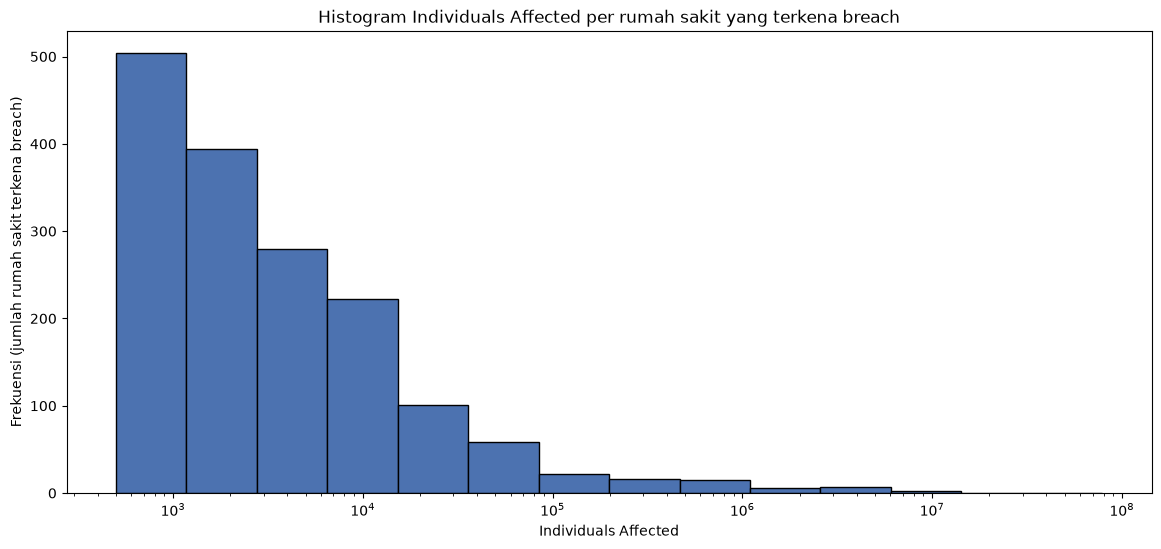

Range_Affected
(500.0, 1175.504]              504
(1175.504, 2763.618]           394
(2763.618, 6497.287]           280
(6497.287, 15275.17]           222
(15275.17, 35912.04]           101
(35912.04, 84429.476]           59
(84429.476, 198494.332]         22
(198494.332, 466661.665]        16
(466661.665, 1097125.076]       15
(1097125.076, 2579349.285]       6
(2579349.285, 6064069.524]       7
(6064069.524, 14256672.953]      2
Name: count, dtype: int64


In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = df_rapi["Individuals Affected"].dropna()

log_bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 15) 

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(data, bins=log_bins, color="#4C72B0", edgecolor="black")
ax.set_xscale("log") # Kita set sumbu x nya menggunakan log 10 (10 pangkat), karena datanya terdapat outlier yang SANGAT ekstrem
ax.set_title("Histogram Individuals Affected per perusahaan yang terkena breach")
ax.set_xlabel("Individuals Affected")
ax.set_ylabel("Frekuensi (jumlah rumah sakit terkena breach)")
plt.savefig("hist_individuals_affected_log_bins.png", dpi=150)
plt.show()

df_binned = df_rapi.copy()
df_binned["Range_Affected"] = pd.cut(data, bins=log_bins)

freq_table = df_binned["Range_Affected"].value_counts().sort_index()
freq_table_clean = freq_table[freq_table > 0]
print(freq_table_clean)

**Sebaran data miring ke kanan (right-skewed): sebagian besar perusahaan hanya berdampak ke ratusan sampai ribuan individu, sementara frekuensi menurun drastis seiring bertambahnya jumlah individu, dengan keberadaan oulier ekstrem mencapai jutaan sampai puluhan juta individu yang menarik ekor distribusi jauh ke kanan.**

### Box Plot ###

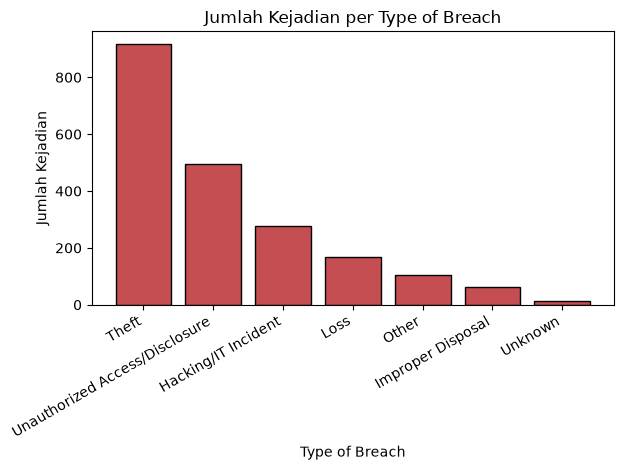

Type of Breach
Theft                             916
Unauthorized Access/Disclosure    494
Hacking/IT Incident               278
Loss                              167
Other                             104
Improper Disposal                  62
Unknown                            13
Name: count, dtype: int64


In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# DIAGRAM BATANG 1 - Type of Breach (jumlah kejadian)
breach_counts = df_exploded['Type of Breach'].value_counts()

fig, ax = plt.subplots()
ax.bar(breach_counts.index, breach_counts.values, color="#C44E52", edgecolor="black")
ax.set_title("Jumlah perusahaan per Type of Breach")
ax.set_xlabel("Type of Breach")
ax.set_ylabel("Jumlah Kejadian")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bar_type_of_breach.png", dpi=150)
plt.show()

print(breach_counts)


**Kejadian breach paling banyak disebabkan oleh Theft, diikuti Unauthorized Access/Disclosure, sementara Unknown adalah jenis breach paling jarang terjadi.**

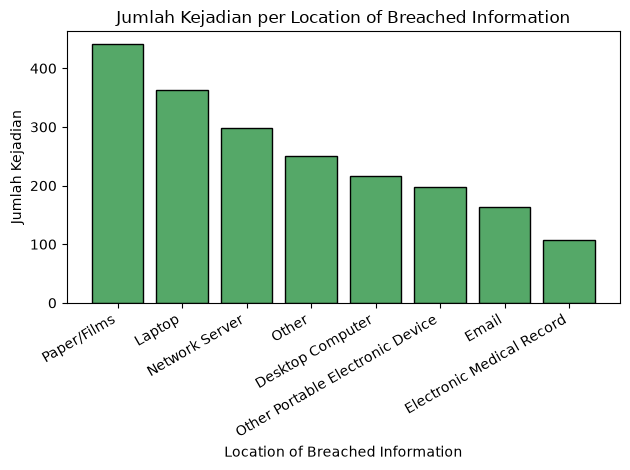

Location of Breached Information
Paper/Films                         441
Laptop                              363
Network Server                      298
Other                               250
Desktop Computer                    217
Other Portable Electronic Device    197
Email                               164
Electronic Medical Record           107
Name: count, dtype: int64


In [17]:
# DIAGRAM BATANG 2 - Location of Breached Information (jumlah kejadian)
location_counts = df_exploded['Location of Breached Information'].value_counts()

fig, ax = plt.subplots()
ax.bar(location_counts.index, location_counts.values, color="#55A868", edgecolor="black")
ax.set_title("Jumlah perusahaan per Location of Breached Information")
ax.set_xlabel("Location of Breached Information")
ax.set_ylabel("Jumlah Kejadian")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bar_location_of_breach.png", dpi=150)
plt.show()

print(location_counts)

**Lokasi/ media breach paling sering terjadi pada Paper/Films dan Laptop, sedangkan Electronic Medical Record menjadi lokasi breach yang paling jarang tercatat.**

### Box Plot ###

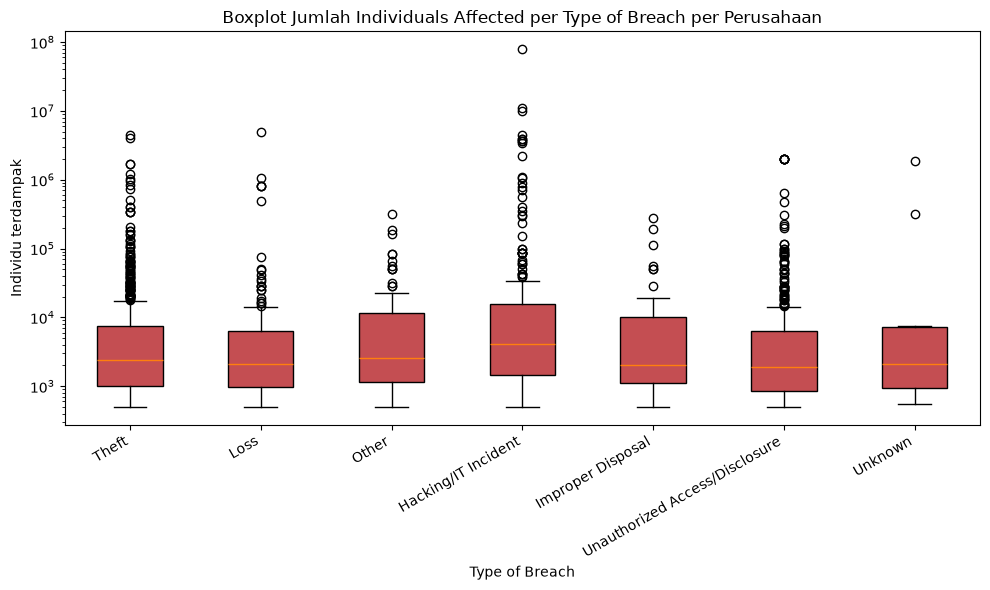

In [64]:
import numpy as np

# Buang baris yang Type of Breach-nya kosong (NaN)
kategori_breach = df_exploded["Type of Breach"].dropna().unique()

data_per_breach = [
    df_exploded.loc[df_exploded["Type of Breach"] == kat, "Individuals Affected"].dropna()
    for kat in kategori_breach
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_per_breach, tick_labels=kategori_breach, patch_artist=True,
           boxprops=dict(facecolor="#C44E52"))
ax.set_yscale("log")   # <-- kunci biar kotak keliatan
ax.set_title("Boxplot Jumlah Individuals Affected per Type of Breach per Perusahaan")
ax.set_xlabel("Type of Breach")
ax.set_ylabel("Individu terdampak")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("boxplot_by_breach_type.png", dpi=150)
plt.show()

**Berdasarkan aturan 1,5×IQR, hampir semua kategori memiliki pencilan (outlier) di sisi atas, terlihat dari banyaknya titik lingkaran di atas whisker atas pada tiap kategori. Hacking/IT Incident memiliki median tertinggi dan outlier paling ekstrem (hingga kurang lebih 10^8 atau 100 juta orang), menunjukkan jenis breach ini paling berisiko berdampak sangat luas dibanding jenis lainnya.**

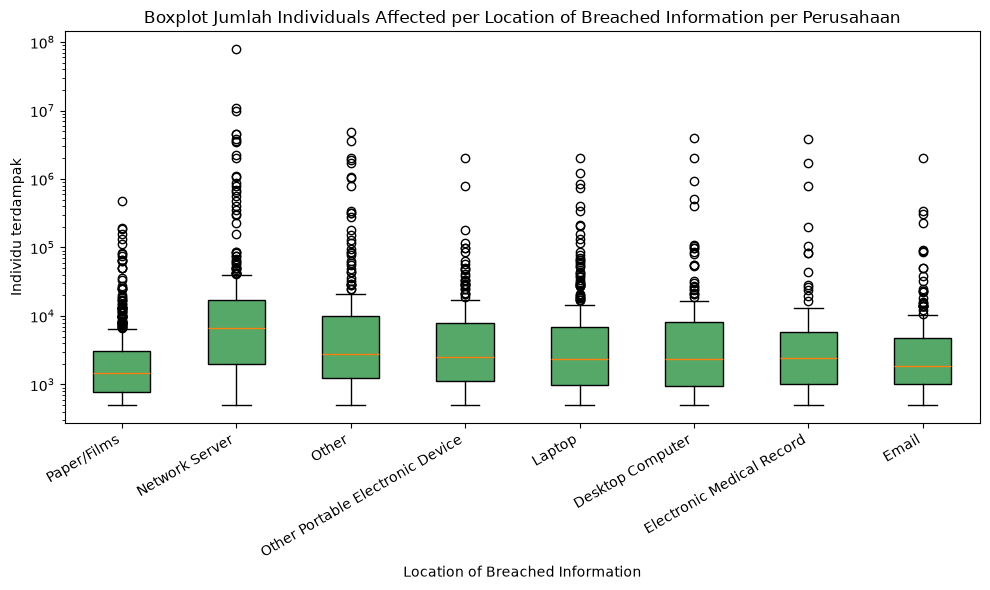

In [65]:
# Buang kategori kosong (NaN) juga di sini
kategori_lokasi = df_exploded["Location of Breached Information"].dropna().unique()

data_per_lokasi = [
    df_exploded.loc[df_exploded["Location of Breached Information"] == kat, "Individuals Affected"].dropna()
    for kat in kategori_lokasi
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_per_lokasi, tick_labels=kategori_lokasi, patch_artist=True,
           boxprops=dict(facecolor="#55A868"))
ax.set_yscale("log")   # <-- biar kotak keliatan, sama seperti boxplot sebelumnya
ax.set_title("Boxplot Jumlah Individuals Affected per Location of Breached Information per Perusahaan")
ax.set_xlabel("Location of Breached Information")
ax.set_ylabel("Individu terdampak")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("boxplot_by_location.png", dpi=150)
plt.show()

**Sama seperti boxplot sebelumnya, hampir seluruh kategori lokasi menunjukkan pencilan di atas batas 1,5×IQR. Network Server memiliki median tertinggi serta outlier paling ekstrem, mengindikasikan breach yang terjadi pada server jaringan cenderung berdampak pada jumlah individu jauh lebih besar dibanding lokasi fisik seperti Paper/Films.**